# PS1: Phân tích doanh thu theo địa giới

**Yêu cầu:** Ánh xạ và tổng hợp doanh thu theo phân cấp **Region → City → District** để xác định các thị trường có doanh thu cao nhất.

**Quy ước ghi nhận doanh thu:**

- Đơn `delivered`: doanh thu thuần bằng `payment_value`.
- Đơn `returned`: doanh thu thuần bằng `payment_value - total_refund`.
- Không ghi nhận các đơn `created`, `paid`, `shipped` và `cancelled` vào doanh thu hoàn tất.
- Đơn `returned` thiếu thông tin hoàn tiền được loại khỏi phép tổng hợp. Trường hợp tiền hoàn lớn hơn tiền thanh toán vẫn được giữ vì có thể bao gồm khoản đền bù, khi đó doanh thu thuần của đơn có thể âm.


## 1. Import thư viện và đọc dữ liệu

Notebook tự nhận đường dẫn khi chạy từ thư mục dự án hoặc từ thư mục chứa notebook.


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = "../../SilverData"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "SilverData"

orders = pd.read_csv(
    f"{DATA_DIR}/orders_silver.csv",
    dtype={"zip": "string"},
    parse_dates=["order_date"]
)
geography = pd.read_csv(
    f"{DATA_DIR}/geography_silver.csv",
    dtype={"zip": "string"}
)
payments = pd.read_csv(f"{DATA_DIR}/payments_silver.csv")
returns = pd.read_csv(
    f"{DATA_DIR}/returns_silver.csv",
    parse_dates=["return_date"]
)

print("Orders:", orders.shape)
print("Geography:", geography.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)


Orders: (646945, 9)
Geography: (39948, 4)
Payments: (646945, 4)
Returns: (39939, 7)


## 2. Kiểm tra khóa và trạng thái đơn hàng

Các khóa phải phù hợp trước khi ghép để tránh nhân đôi doanh thu.


In [10]:
print("ZIP trùng trong geography:", geography["zip"].duplicated().sum())
print("order_id trùng trong orders:", orders["order_id"].duplicated().sum())
print("order_id trùng trong payments:", payments["order_id"].duplicated().sum())
print("Số order có nhiều dòng return:", returns["order_id"].duplicated().sum())

print("\nTrạng thái đơn hàng:")
display(
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)


ZIP trùng trong geography: 0
order_id trùng trong orders: 0
order_id trùng trong payments: 0
Số order có nhiều dòng return: 3877

Trạng thái đơn hàng:


,order_status,order_count
0,delivered,516716
1,cancelled,59462
2,returned,36142
3,shipped,13773
4,paid,13577
5,created,7275


## 3. Gộp hoàn tiền theo đơn hàng

Một đơn có thể trả nhiều sản phẩm hoặc trả nhiều lần. Vì vậy phải cộng `refund_amount` theo `order_id` trước khi ghép với đơn hàng.


In [11]:
refund_by_order = (
    returns.groupby("order_id", as_index=False)
    .agg(
        total_refund=("refund_amount", "sum"),
        return_rows=("return_id", "count"),
        returned_quantity=("return_quantity", "sum")
    )
)

print("Số đơn có hoàn trả:", len(refund_by_order))
print("Số đơn có nhiều hơn một dòng hoàn trả:", (refund_by_order["return_rows"] > 1).sum())
display(refund_by_order.head())


Số đơn có hoàn trả: 36062
Số đơn có nhiều hơn một dòng hoàn trả: 3801


,order_id,total_refund,return_rows,returned_quantity
0,2,52458.01,1,6
1,32,5141.37,1,2
2,35,5315.95,1,1
3,47,8234.51,2,5
4,59,10086.33,1,1


## 4. Ghép đơn hàng, địa giới, thanh toán và hoàn trả

- `orders.zip → geography.zip`
- `orders.order_id → payments.order_id`
- `orders.order_id → refund_by_order.order_id`


In [12]:
df = (
    orders
    .merge(
        geography,
        on="zip",
        how="left",
        validate="many_to_one",
        indicator="geo_match"
    )
    .merge(
        payments,
        on="order_id",
        how="left",
        validate="one_to_one",
        indicator="payment_match"
    )
    .merge(
        refund_by_order,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

print("Số đơn trước khi ghép:", len(orders))
print("Số dòng sau khi ghép:", len(df))
print("Đơn không khớp địa giới:", (df["geo_match"] != "both").sum())
print("Đơn không khớp payment:", (df["payment_match"] != "both").sum())
print("Giá trị địa giới bị thiếu:")
display(df[["region", "city", "district"]].isna().sum())


Số đơn trước khi ghép: 646945
Số dòng sau khi ghép: 646945
Đơn không khớp địa giới: 0
Đơn không khớp payment: 0
Giá trị địa giới bị thiếu:


region      0
city        0
district    0
dtype: int64

## 5. Kiểm tra payment và return theo trạng thái

Phần này xác nhận bản ghi hoàn trả thuộc trạng thái nào và phát hiện các trường hợp không đủ điều kiện tính doanh thu thuần.


In [13]:
df["has_payment"] = df["payment_value"].notna()
df["has_return"] = df["total_refund"].notna()

status_summary = (
    df.groupby("order_status", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        payment_count=("has_payment", "sum"),
        return_order_count=("has_return", "sum"),
        payment_total=("payment_value", "sum"),
        refund_total=("total_refund", "sum")
    )
    .sort_values("order_count", ascending=False)
)

display(status_summary)


,order_status,order_count,payment_count,return_order_count,payment_total,refund_total
2,delivered,516716,516716,0,1.251818e+10,0.000000e+00
0,cancelled,59462,59462,0,1.447014e+09,0.000000e+00
4,returned,36142,36142,36062,8.659387e+08,5.105985e+08
5,shipped,13773,13773,0,3.372788e+08,0.000000e+00
3,paid,13577,13577,0,3.306271e+08,0.000000e+00
1,created,7275,7275,0,1.818350e+08,0.000000e+00


## 6. Tạo dữ liệu doanh thu hợp lệ

Chỉ sử dụng đơn `delivered` và `returned`. Đơn `returned` thiếu dữ liệu hoàn tiền bị loại; đơn có tiền hoàn vượt tiền thanh toán vẫn được giữ và đánh dấu vì khoản hoàn có thể bao gồm tiền đền bù.


In [14]:
df_revenue = df.loc[
    df["order_status"].isin(["delivered", "returned"])
].copy()

df_revenue["refund_quality"] = "valid"

missing_refund = (
    df_revenue["order_status"].eq("returned")
    & df_revenue["total_refund"].isna()
)
refund_exceeds_payment = (
    df_revenue["order_status"].eq("returned")
    & df_revenue["total_refund"].gt(df_revenue["payment_value"])
)

df_revenue.loc[missing_refund, "refund_quality"] = "missing_refund"
df_revenue["refund_exceeds_payment"] = refund_exceeds_payment

print("Kiểm tra chất lượng hoàn tiền:")
display(
    df_revenue["refund_quality"]
    .value_counts()
    .rename_axis("refund_quality")
    .reset_index(name="order_count")
)

df_revenue_valid = df_revenue.loc[
    df_revenue["refund_quality"].eq("valid")
].copy()

df_revenue_valid["total_refund"] = df_revenue_valid["total_refund"].fillna(0)
df_revenue_valid["gross_revenue"] = df_revenue_valid["payment_value"]
df_revenue_valid["net_revenue"] = (
    df_revenue_valid["gross_revenue"]
    - df_revenue_valid["total_refund"]
)

print("Số đơn được dùng để tính doanh thu:", len(df_revenue_valid))
print(
    "Số đơn có tiền hoàn vượt payment (vẫn được giữ):",
    df_revenue_valid["refund_exceeds_payment"].sum()
)
print(
    "Số đơn có doanh thu thuần âm:",
    (df_revenue_valid["net_revenue"] < 0).sum()
)
print("Doanh thu gộp: {:,.0f}".format(df_revenue_valid["gross_revenue"].sum()))
print("Tiền hoàn trả: {:,.0f}".format(df_revenue_valid["total_refund"].sum()))
print("Doanh thu thuần: {:,.0f}".format(df_revenue_valid["net_revenue"].sum()))


Kiểm tra chất lượng hoàn tiền:


,refund_quality,order_count
0,valid,552778
1,missing_refund,80


Số đơn được dùng để tính doanh thu: 552778
Số đơn có tiền hoàn vượt payment (vẫn được giữ): 3640
Số đơn có doanh thu thuần âm: 3640
Doanh thu gộp: 13,382,330,429
Tiền hoàn trả: 510,598,507
Doanh thu thuần: 12,871,731,922


## 7. Doanh thu thuần theo Region

Bảng thể hiện doanh thu gộp, tiền hoàn trả, doanh thu thuần, tỷ trọng và thứ hạng của từng Region.


In [15]:
revenue_region = (
    df_revenue_valid.groupby("region", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        refund_amount=("total_refund", "sum"),
        net_revenue=("net_revenue", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique")
    )
    .sort_values("net_revenue", ascending=False)
    .reset_index(drop=True)
)

revenue_region["net_share_pct"] = (
    revenue_region["net_revenue"] / revenue_region["net_revenue"].sum() * 100
).round(2)
revenue_region["refund_rate_pct"] = (
    revenue_region["refund_amount"] / revenue_region["gross_revenue"] * 100
).round(2)
revenue_region["rank"] = range(1, len(revenue_region) + 1)

region_display = revenue_region.copy()
for column in ["gross_revenue", "refund_amount", "net_revenue"]:
    region_display[column] = region_display[column].map("{:,.0f}".format)

display(region_display[[
    "rank", "region", "gross_revenue", "refund_amount", "net_revenue",
    "net_share_pct", "refund_rate_pct", "order_count", "customer_count"
]])


,rank,region,gross_revenue,refund_amount,net_revenue,net_share_pct,refund_rate_pct,order_count,customer_count
0,1,East,"6,222,991,469","235,481,748","5,987,509,721",46.52,3.78,251667,43071
1,2,Central,"4,021,685,300","151,387,098","3,870,298,201",30.07,3.76,157613,29359
2,3,West,"3,137,653,660","123,729,660","3,013,923,999",23.42,3.94,143498,14259


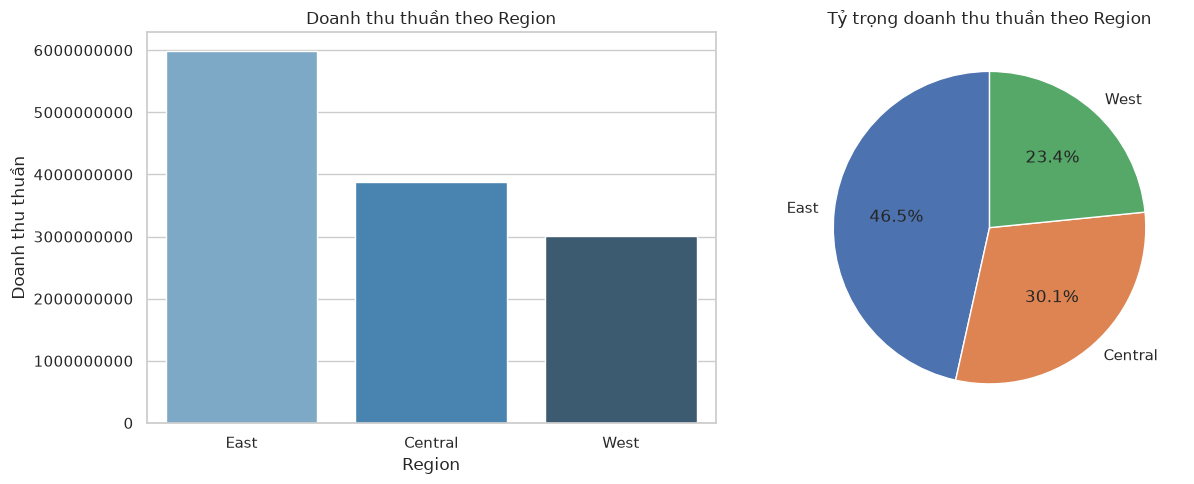

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=revenue_region,
    x="region",
    y="net_revenue",
    hue="region",
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Doanh thu thuần theo Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Doanh thu thuần")
axes[0].ticklabel_format(style="plain", axis="y")

axes[1].pie(
    revenue_region["net_revenue"],
    labels=revenue_region["region"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Tỷ trọng doanh thu thuần theo Region")

plt.tight_layout()
plt.show()


## 8. Doanh thu thuần theo City trong từng Region

Nhóm theo `region + city` để giữ đúng phân cấp địa giới.


In [17]:
revenue_city = (
    df_revenue_valid.groupby(["region", "city"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        refund_amount=("total_refund", "sum"),
        net_revenue=("net_revenue", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique")
    )
    .sort_values("net_revenue", ascending=False)
    .reset_index(drop=True)
)

revenue_city["net_share_pct"] = (
    revenue_city["net_revenue"] / revenue_city["net_revenue"].sum() * 100
).round(2)
revenue_city["rank"] = range(1, len(revenue_city) + 1)
revenue_city["location"] = revenue_city["city"] + " (" + revenue_city["region"] + ")"

city_display = revenue_city.head(10).copy()
for column in ["gross_revenue", "refund_amount", "net_revenue"]:
    city_display[column] = city_display[column].map("{:,.0f}".format)

display(city_display[[
    "rank", "region", "city", "gross_revenue", "refund_amount",
    "net_revenue", "net_share_pct", "order_count", "customer_count"
]])


,rank,region,city,gross_revenue,refund_amount,net_revenue,net_share_pct,order_count,customer_count
0,1,East,Son Tay,"472,592,676","17,357,019","455,235,657",3.54,19135,3130
1,2,East,Nam Dinh,"467,427,043","16,754,685","450,672,358",3.50,18605,3060
2,3,East,Thai Nguyen,"460,791,036","18,232,432","442,558,604",3.44,18728,3208
3,4,East,Hanoi,"456,569,558","16,580,682","439,988,877",3.42,18430,3058
4,5,East,Phu Ly,"455,595,181","18,251,989","437,343,192",3.40,18247,3164
5,6,East,Ninh Binh,"448,498,635","16,579,891","431,918,744",3.36,18003,2972
6,7,East,Hai Phong,"447,466,804","16,642,371","430,824,434",3.35,18046,3091
7,8,East,Ha Long,"445,535,755","17,380,842","428,154,913",3.33,17939,3123
8,9,East,Viet Tri,"442,942,669","16,399,680","426,542,989",3.31,17807,3051
9,10,East,Bac Giang,"435,776,076","16,756,544","419,019,532",3.26,17825,3115


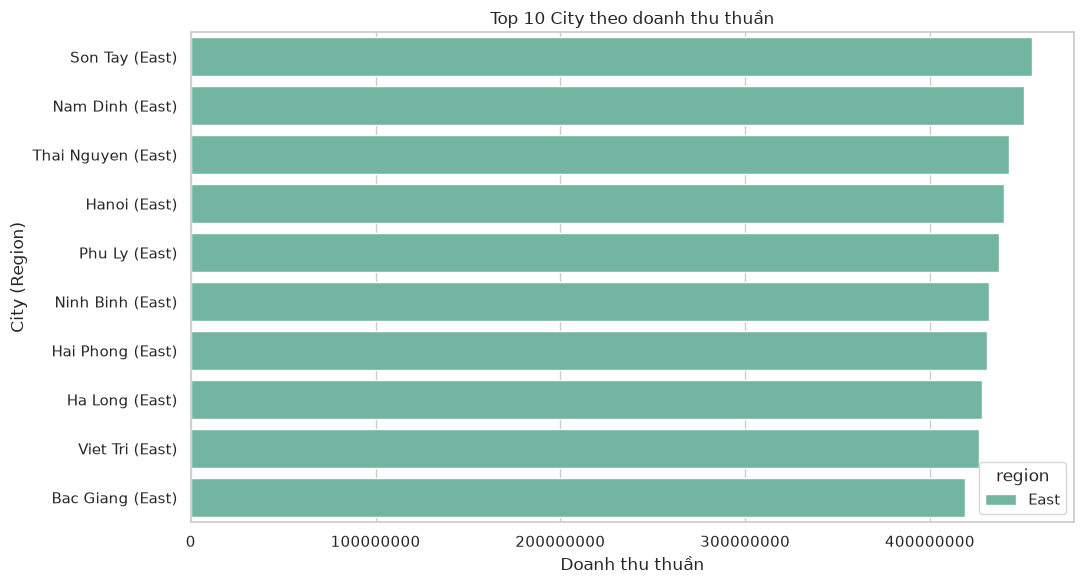

In [18]:
top_city = revenue_city.head(10)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_city,
    x="net_revenue",
    y="location",
    hue="region",
    dodge=False,
    palette="Set2"
)
plt.title("Top 10 City theo doanh thu thuần")
plt.xlabel("Doanh thu thuần")
plt.ylabel("City (Region)")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


## 9. Doanh thu thuần theo District trong từng City và Region

Không nhóm riêng theo tên District vì cùng một tên District có thể xuất hiện tại nhiều City.


In [19]:
revenue_district = (
    df_revenue_valid.groupby(["region", "city", "district"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        refund_amount=("total_refund", "sum"),
        net_revenue=("net_revenue", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique")
    )
    .sort_values("net_revenue", ascending=False)
    .reset_index(drop=True)
)

revenue_district["net_share_pct"] = (
    revenue_district["net_revenue"] / revenue_district["net_revenue"].sum() * 100
).round(2)
revenue_district["rank"] = range(1, len(revenue_district) + 1)
revenue_district["location"] = (
    revenue_district["district"] + " - "
    + revenue_district["city"] + " ("
    + revenue_district["region"] + ")"
)

district_display = revenue_district.head(10).copy()
for column in ["gross_revenue", "refund_amount", "net_revenue"]:
    district_display[column] = district_display[column].map("{:,.0f}".format)

display(district_display[[
    "rank", "region", "city", "district", "gross_revenue",
    "refund_amount", "net_revenue", "net_share_pct",
    "order_count", "customer_count"
]])


,rank,region,city,district,gross_revenue,refund_amount,net_revenue,net_share_pct,order_count,customer_count
0,1,East,Thai Nguyen,District #10,"62,350,640","2,393,178","59,957,462",0.47,2420,212
1,2,West,Pleiku,District #38,"60,764,224","2,274,446","58,489,778",0.45,2866,135
2,3,West,Vung Tau,District #37,"58,828,619","2,334,638","56,493,982",0.44,2570,151
3,4,Central,Kon Tum,District #22,"55,450,864","1,713,494","53,737,370",0.42,2081,243
4,5,Central,Dong Hoi,District #23,"51,386,896","1,475,449","49,911,446",0.39,1905,235
5,6,Central,Quy Nhon,District #23,"50,124,130","1,866,790","48,257,340",0.37,1874,260
6,7,Central,Hue,District #23,"49,081,928","1,859,652","47,222,277",0.37,1845,254
7,8,Central,Phan Thiet,District #31,"47,524,076","1,605,703","45,918,373",0.36,1732,205
8,9,Central,Hue,District #22,"46,965,917","1,315,307","45,650,610",0.35,1763,202
9,10,West,Soc Trang,District #37,"47,585,004","2,091,241","45,493,762",0.35,2197,140


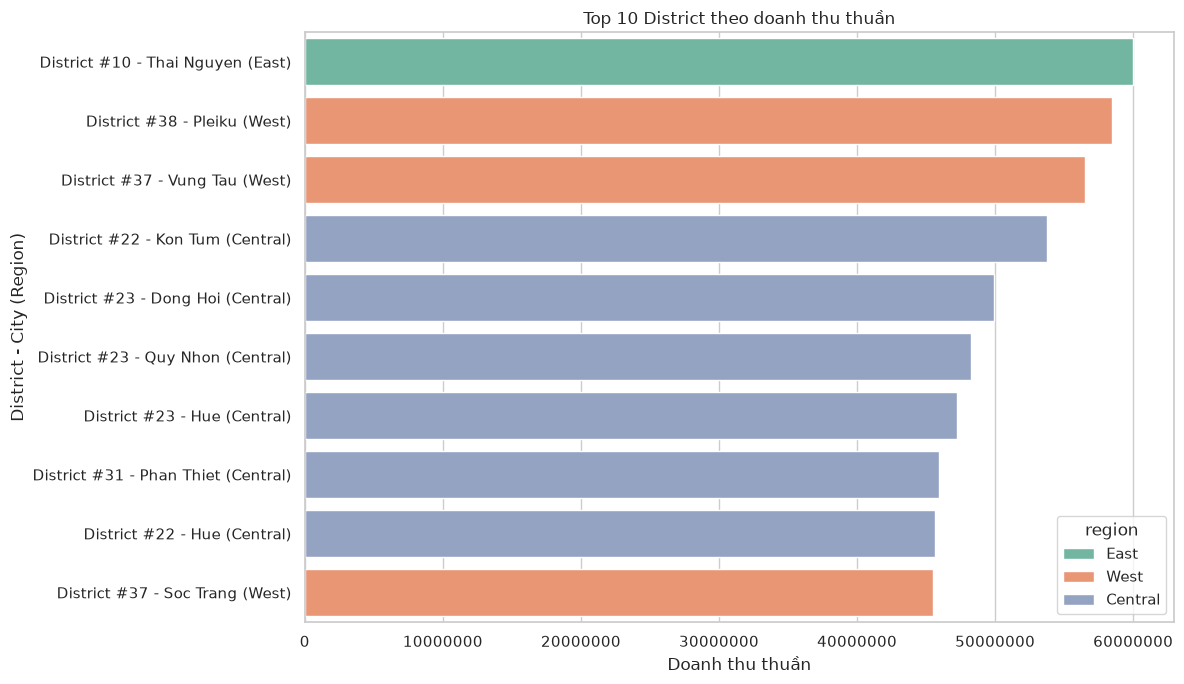

In [20]:
top_district = revenue_district.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_district,
    x="net_revenue",
    y="location",
    hue="region",
    dodge=False,
    palette="Set2"
)
plt.title("Top 10 District theo doanh thu thuần")
plt.xlabel("Doanh thu thuần")
plt.ylabel("District - City (Region)")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


## 10. Khoanh vùng thị trường trọng điểm

Sử dụng nguyên tắc Pareto: các địa bàn được xếp theo doanh thu thuần giảm dần và lần lượt chọn cho đến khi bao phủ **ít nhất 80% tổng doanh thu thuần**. Nhóm này được xem là thị trường trọng điểm theo quy mô doanh thu hiện tại.


In [21]:
def identify_key_markets(data, revenue_col="net_revenue", threshold=80):
    result = data.sort_values(revenue_col, ascending=False).copy()
    result = result.reset_index(drop=True)

    result["share_pct"] = (
        result[revenue_col] / result[revenue_col].sum() * 100
    )
    result["cumulative_share_pct"] = result["share_pct"].cumsum()

    # Chọn cả địa bàn làm tổng cộng dồn vượt qua mốc 80%.
    previous_cumulative = (
        result["cumulative_share_pct"] - result["share_pct"]
    )
    result["market_group"] = "Thị trường bổ sung"
    result.loc[
        previous_cumulative < threshold,
        "market_group"
    ] = "Thị trường trọng điểm"

    return result


market_region = identify_key_markets(revenue_region)
market_city = identify_key_markets(revenue_city)
market_district = identify_key_markets(revenue_district)

key_regions = market_region.loc[
    market_region["market_group"].eq("Thị trường trọng điểm")
].copy()
key_cities = market_city.loc[
    market_city["market_group"].eq("Thị trường trọng điểm")
].copy()
key_districts = market_district.loc[
    market_district["market_group"].eq("Thị trường trọng điểm")
].copy()

print("Số Region trọng điểm:", len(key_regions))
print("Số City trọng điểm:", len(key_cities))
print("Số District trọng điểm:", len(key_districts))
print("Tỷ trọng City trọng điểm bao phủ: {:.2f}%".format(
    key_cities["share_pct"].sum()
))
print("Tỷ trọng District trọng điểm bao phủ: {:.2f}%".format(
    key_districts["share_pct"].sum()
))


Số Region trọng điểm: 3
Số City trọng điểm: 28
Số District trọng điểm: 369
Tỷ trọng City trọng điểm bao phủ: 80.09%
Tỷ trọng District trọng điểm bao phủ: 80.11%


In [22]:
key_region_display = key_regions[[
    "region", "net_revenue", "share_pct", "cumulative_share_pct", "market_group"
]].copy()
key_region_display["net_revenue"] = key_region_display["net_revenue"].map("{:,.0f}".format)

key_city_display = key_cities[[
    "region", "city", "net_revenue", "share_pct",
    "cumulative_share_pct", "market_group"
]].copy()
key_city_display["net_revenue"] = key_city_display["net_revenue"].map("{:,.0f}".format)

key_district_display = key_districts[[
    "region", "city", "district", "net_revenue", "share_pct",
    "cumulative_share_pct", "market_group"
]].copy()
key_district_display["net_revenue"] = key_district_display["net_revenue"].map("{:,.0f}".format)

print("REGION TRỌNG ĐIỂM")
display(key_region_display)

print("CITY TRỌNG ĐIỂM")
display(key_city_display)

print("DISTRICT TRỌNG ĐIỂM")
display(key_district_display)


REGION TRỌNG ĐIỂM


,region,net_revenue,share_pct,cumulative_share_pct,market_group
0,East,"5,987,509,721",46.516737,46.516737,Thị trường trọng điểm
1,Central,"3,870,298,201",30.068201,76.584938,Thị trường trọng điểm
2,West,"3,013,923,999",23.415062,100.000000,Thị trường trọng điểm


CITY TRỌNG ĐIỂM


,region,city,net_revenue,share_pct,cumulative_share_pct,market_group
0,East,Son Tay,"455,235,657",3.536709,3.536709,Thị trường trọng điểm
1,East,Nam Dinh,"450,672,358",3.501257,7.037965,Thị trường trọng điểm
2,East,Thai Nguyen,"442,558,604",3.438221,10.476186,Thị trường trọng điểm
3,East,Hanoi,"439,988,877",3.418257,13.894443,Thị trường trọng điểm
4,East,Phu Ly,"437,343,192",3.397703,17.292146,Thị trường trọng điểm
5,East,Ninh Binh,"431,918,744",3.355560,20.647707,Thị trường trọng điểm
6,East,Hai Phong,"430,824,434",3.347059,23.994765,Thị trường trọng điểm
7,East,Ha Long,"428,154,913",3.326319,27.321085,Thị trường trọng điểm
8,East,Viet Tri,"426,542,989",3.313796,30.634881,Thị trường trọng điểm
9,East,Bac Giang,"419,019,532",3.255347,33.890228,Thị trường trọng điểm


DISTRICT TRỌNG ĐIỂM


,region,city,district,net_revenue,share_pct,cumulative_share_pct,market_group
0,East,Thai Nguyen,District #10,"59,957,462",0.465807,0.465807,Thị trường trọng điểm
1,West,Pleiku,District #38,"58,489,778",0.454405,0.920212,Thị trường trọng điểm
2,West,Vung Tau,District #37,"56,493,982",0.438900,1.359112,Thị trường trọng điểm
3,Central,Kon Tum,District #22,"53,737,370",0.417484,1.776595,Thị trường trọng điểm
4,Central,Dong Hoi,District #23,"49,911,446",0.387760,2.164356,Thị trường trọng điểm
...,...,...,...,...,...,...,...
364,Central,Quy Nhon,District #21,"19,937,016",0.154890,79.493551,Thị trường trọng điểm
365,East,Lao Cai,District #17,"19,917,060",0.154735,79.648286,Thị trường trọng điểm
366,East,Lao Cai,District #07,"19,895,028",0.154564,79.802850,Thị trường trọng điểm
367,East,Nam Dinh,District #02,"19,852,212",0.154231,79.957081,Thị trường trọng điểm


## 11. Kết luận

Kết quả dưới đây lấy trực tiếp từ bảng tổng hợp doanh thu thuần.


In [23]:
top_region = revenue_region.iloc[0]
top_city = revenue_city.iloc[0]
top_district = revenue_district.iloc[0]

print(
    "Region dẫn đầu: {} với doanh thu thuần {:,.0f}, chiếm {:.2f}% tổng doanh thu thuần.".format(
        top_region["region"], top_region["net_revenue"], top_region["net_share_pct"]
    )
)
print(
    "City dẫn đầu: {}, Region {}, với doanh thu thuần {:,.0f}.".format(
        top_city["city"], top_city["region"], top_city["net_revenue"]
    )
)
print(
    "District dẫn đầu: {}, City {}, Region {}, với doanh thu thuần {:,.0f}.".format(
        top_district["district"], top_district["city"],
        top_district["region"], top_district["net_revenue"]
    )
)


Region dẫn đầu: East với doanh thu thuần 5,987,509,721, chiếm 46.52% tổng doanh thu thuần.
City dẫn đầu: Son Tay, Region East, với doanh thu thuần 455,235,657.
District dẫn đầu: District #10, City Thai Nguyen, Region East, với doanh thu thuần 59,957,462.
